# 01 — Data Exploration
**NewsBot Intelligence System 2.0 | ITAI 2373**

Load the BBC News dataset, explore its structure, and prepare `df_final` for downstream modules.

In [ ]:
%pip install kaggle pandas matplotlib seaborn wordcloud -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
from collections import Counter
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2d3561','axes.labelcolor':'#e8d5a3',
    'xtick.color':'#a0a8c0','ytick.color':'#a0a8c0',
    'text.color':'#e8d5a3','grid.color':'#2d3561',
    'grid.alpha':0.5,'figure.dpi':120
})
PALETTE = {'tech':'#4fc3f7','business':'#81c784','politics':'#e57373',
           'sport':'#ffb74d','entertainment':'#ce93d8'}
print('Setup complete.')


Setup complete.


## 1.1 — Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/ITAI2373-NewsBot-Final'
os.makedirs(f'{PROJECT}/data/processed', exist_ok=True)
os.makedirs(f'{PROJECT}/data/models', exist_ok=True)
os.chdir(PROJECT)
print('Working dir:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/ITAI2373-NewsBot-Final


In [ ]:
import os
from google.colab import userdata
os.environ['KAGGLE_KEY'] = userdata.get('kaggleaccess_token')
kagglehub.login()

In [ ]:

# Download latest version
path = kagglehub.competition_download('learn-ai-bbc')

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/competitions/learn-ai-bbc


In [ ]:
import os
for file in os.listdir(path):
    if file == 'BBC News Train.csv': # Look for the specific train.csv file
        csv_path = os.path.join(path, file)
        df = pd.read_csv(csv_path)
        print(f"Loaded {file} with shape:", df.shape)
        break

print(f"Original dataset shape: {df.shape}")
print(f"Sampled dataset shape: {df.shape}")
print(f"Categories: {df['Category'].unique()}")

Loaded BBC News Train.csv with shape: (1490, 3)
Original dataset shape: (1490, 3)
Sampled dataset shape: (1490, 3)
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


## 1.2 — Basic Statistics

In [ ]:
print('='*50)
print('  BBC NEWS DATASET OVERVIEW')
print('='*50)
print(f'  Total articles : {len(df):,}')
print(f'  Categories     : {df.Category.nunique()}')
print(f'  Null values    : {df.isnull().sum().sum()}')
print(f'  Duplicates     : {df.Text.duplicated().sum()}')
print()
print('Category distribution:')
print(df.Category.value_counts())


  BBC NEWS DATASET OVERVIEW
  Total articles : 1,490
  Categories     : 5
  Null values    : 0
  Duplicates     : 50

Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


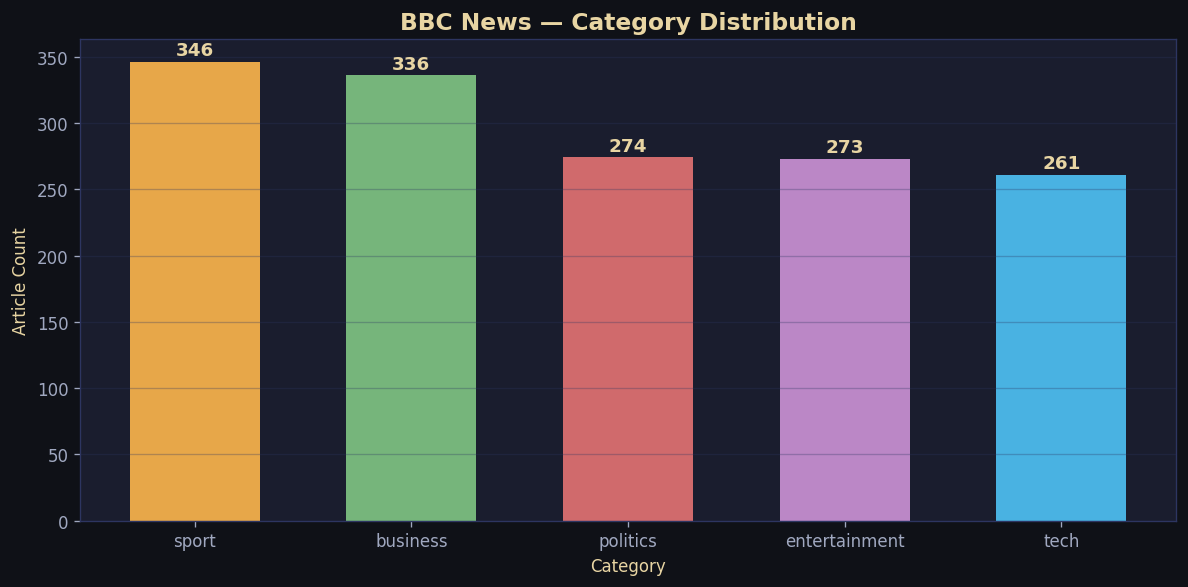

In [ ]:
# Category bar chart
cat_counts = df.Category.value_counts()
colors = [PALETTE.get(c,'#ffffff') for c in cat_counts.index]

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=colors, alpha=0.9, width=0.6)
for bar,cnt in zip(bars, cat_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(cnt), ha='center', fontsize=11, fontweight='bold')
ax.set_title('BBC News — Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Article Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('category_distribution.png',bbox_inches='tight',dpi=150,facecolor='#0f1117')
plt.show()


## 1.3 — Text Length Analysis

Text length statistics:
               text_length  word_count
Category                              
business            1983.0       334.0
entertainment       1910.0       334.0
politics            2618.0       450.0
sport               1895.0       335.0
tech                2939.0       502.0


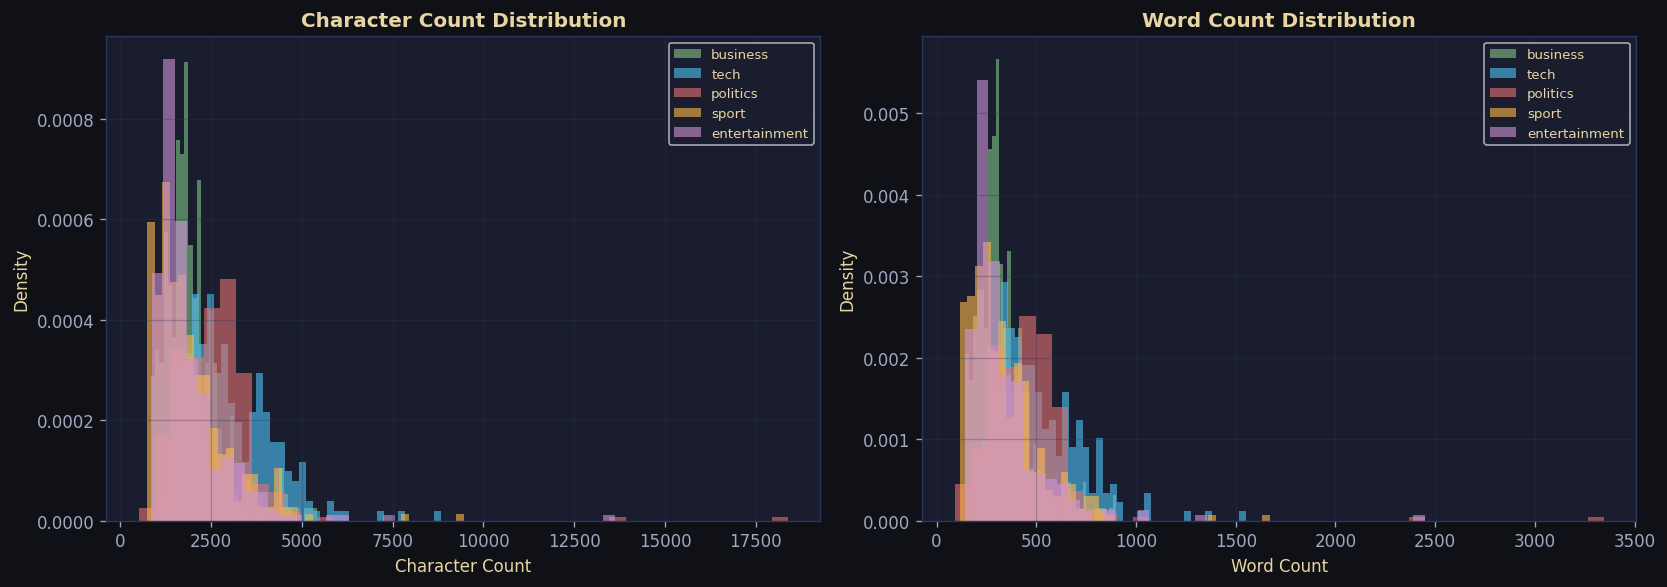

In [ ]:
df['text_length'] = df.Text.str.len()
df['word_count']  = df.Text.str.split().str.len()

print('Text length statistics:')
print(df.groupby('Category')[['text_length','word_count']].mean().round(0))

fig, axes = plt.subplots(1,2,figsize=(14,5))
for i,(col,label) in enumerate([('text_length','Character Count'),('word_count','Word Count')]):
    ax = axes[i]
    for cat in df.Category.unique():
        subset = df[df.Category==cat][col]
        ax.hist(subset, bins=40, alpha=0.6, color=PALETTE.get(cat,'#fff'), label=cat, density=True)
    ax.set_title(f'{label} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('text_length_distribution.png',bbox_inches='tight',dpi=150,facecolor='#0f1117')
plt.show()


## 1.4 — Word Clouds per Category

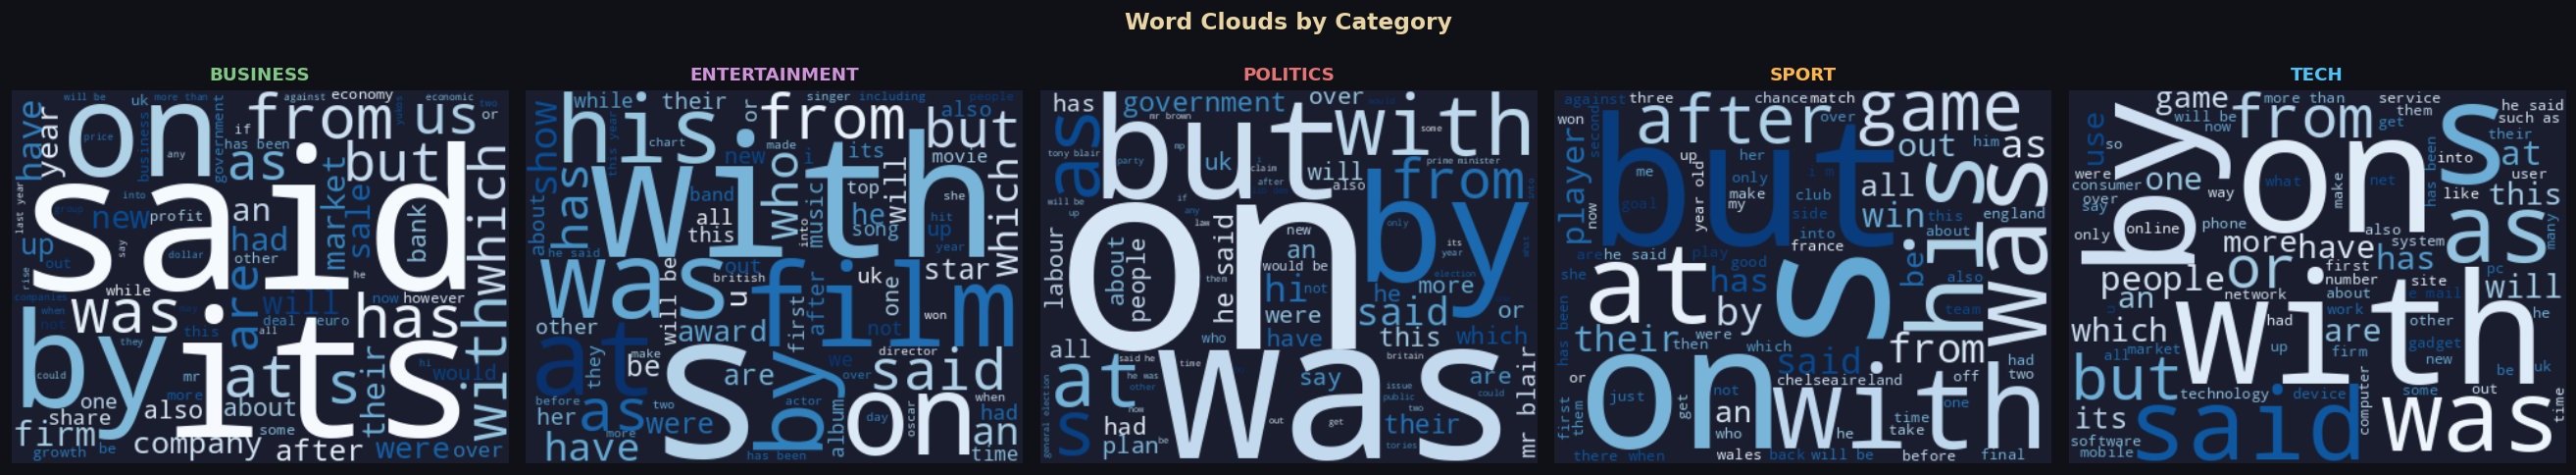

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
categories = sorted(df.Category.unique())

for ax, cat in zip(axes, categories):
    text = ' '.join(df[df.Category==cat].Text.tolist())
    wc = WordCloud(width=400, height=300, background_color='#1a1d2e',
                   colormap='Blues', max_words=80,
                   stopwords={'the','and','to','of','a','in','is','it','that','for'}).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat.upper(), fontsize=11, fontweight='bold', color=PALETTE.get(cat,'#fff'))
    ax.axis('off')

plt.suptitle('Word Clouds by Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png',bbox_inches='tight',dpi=150,facecolor='#0f1117')
plt.show()


## 1.5 — Sample Articles

In [ ]:
print('Sample article from each category:\n')
for cat in sorted(df.Category.unique()):
    sample = df[df.Category==cat].sample(1).iloc[0]
    print(f'[{cat.upper()}]')
    print(sample.Text[:300]+'...')
    print()


Sample article from each category:

[BUSINESS]
ge sees  excellent  world economy us behemoth general electric has posted an 18% jump in quarterly sales  and in profits  and declared itself  in great shape .   we are benefiting from our growth initiatives and an excellent global economy   said ge s chief executive jeff immelt. ge is the us  bigge...

[ENTERTAINMENT]
carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a succes...

[POLITICS]
kilroy-silk quits  shameful  ukip ex-chat show host robert kilroy-silk has quit the uk independence party and accused it of betraying its supporters.  the mep said he was ashamed to have joined the party  which he labelled as a  joke . he plans to stand in the next general election but refused to co...

[SPORT]
mou

## 1.6 — Save df_final

In [ ]:
# df_final is the base DataFrame passed to all subsequent notebooks
df_final = df.copy()
df_final = df_final.dropna(subset=['Text','Category']).reset_index(drop=True)
df_final['doc_id'] = df_final.index

print(f'df_final ready: {df_final.shape}')
print(f'Columns: {list(df_final.columns)}')
df_final.head(3)


df_final ready: (1490, 6)
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id']


,ArticleId,Text,Category,text_length,word_count,doc_id
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866,301,0
1,154,german business confidence slides german busin...,business,2016,325,1
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104,514,2


In [ ]:
# ── Save df_final for next notebook ──────────────────────────────
df_final.to_pickle('data/processed/df_final.pkl')
print(f'Saved df_final: {df_final.shape} → data/processed/df_final.pkl')
print(f'Columns: {list(df_final.columns)}')

Saved df_final: (1490, 6) → data/processed/df_final.pkl
Columns: ['ArticleId', 'Text', 'Category', 'text_length', 'word_count', 'doc_id']
